# Notebook Projet fil rouge b3 Maury Quentin, Quiatol Evan.

## Importation des données 

In [27]:
# connexion à la base dans le même dossier
import sqlite3

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

conn = sqlite3.connect("data/meteo_archive_2010_2026.db")

# lire une table
df = pd.read_sql_query("SELECT * FROM hourly_weather", conn)

# afficher le tableau
print(df)

                       date  temperature_2m  weather_code  wind_speed_10m  \
0       2009-12-31 23:00:00           1.104           3.0       14.145756   
1       2010-01-01 00:00:00           0.954           3.0       14.759999   
2       2010-01-01 01:00:00           0.754           3.0       16.520823   
3       2010-01-01 02:00:00           0.554           3.0       16.099689   
4       2010-01-01 03:00:00           0.454           3.0       15.391840   
...                     ...             ...           ...             ...   
141859  2026-03-08 18:00:00          14.100           0.0        2.885619   
141860  2026-03-08 19:00:00          13.050           0.0        2.577208   
141861  2026-03-08 20:00:00          12.050           0.0        2.545584   
141862  2026-03-08 21:00:00          11.200           0.0        3.640275   
141863  2026-03-08 22:00:00          10.550           0.0        3.784283   

        rain  snowfall  precipitation  wind_speed_100m  snow_depth  \
0    

### Verification des valeurs null 

In [2]:
df.isnull().sum()

date                         0
temperature_2m               0
weather_code                 0
wind_speed_10m               0
rain                         0
snowfall                     0
precipitation                0
wind_speed_100m              0
snow_depth                   0
apparent_temperature         0
relative_humidity_2m         0
cloud_cover                  0
wind_direction_10m           0
soil_temperature_0_to_7cm    0
surface_pressure             0
is_day                       0
sunshine_duration            0
dtype: int64

#### Création de la colonne température moyenne pour chaque saison

In [28]:
df['date'] = pd.to_datetime(df['date'])

def get_saison_astronomique(date):
    md = date.month * 100 + date.day
    if 320 <= md <= 620: return 'Printemps'
    elif 621 <= md <= 921: return 'Été'
    elif 922 <= md <= 1220: return 'Automne'
    else: return 'Hiver'

df['saison_tmp'] = df['date'].apply(get_saison_astronomique)
df['annee_tmp'] = df['date'].dt.year
mask_fin_decembre = (df['date'].dt.month == 12) & (df['date'].dt.day >= 21)
df.loc[mask_fin_decembre, 'annee_tmp'] += 1

df['moyenne_temperature_saison'] = df.groupby(['annee_tmp', 'saison_tmp'])['temperature_2m'].transform('mean')
colonnes_a_virer = ['saison_tmp', 'annee_tmp', 'annee', 'annee_pour_saison']
df = df.drop(columns=[c for c in colonnes_a_virer if c in df.columns])

# sauvegarde
df.to_sql("hourly_weather", conn, if_exists='replace', index=False)

print("Base de données nettoyée et mise à jour !")
print(df.head())

Base de données nettoyée et mise à jour !
                 date  temperature_2m  weather_code  wind_speed_10m  rain  \
0 2009-12-31 23:00:00           1.104           3.0       14.145756   0.0   
1 2010-01-01 00:00:00           0.954           3.0       14.759999   0.0   
2 2010-01-01 01:00:00           0.754           3.0       16.520823   0.0   
3 2010-01-01 02:00:00           0.554           3.0       16.099689   0.0   
4 2010-01-01 03:00:00           0.454           3.0       15.391840   0.0   

   snowfall  precipitation  wind_speed_100m  snow_depth  apparent_temperature  \
0       0.0            0.0        20.620806         0.0             -3.261446   
1       0.0            0.0        21.915693         0.0             -3.543432   
2       0.0            0.0        24.365910         0.0             -4.041818   
3       0.0            0.0        23.936617         0.0             -4.207702   
4       0.0            0.0        23.233253         0.0             -4.238064   

   relat

## Visualisation

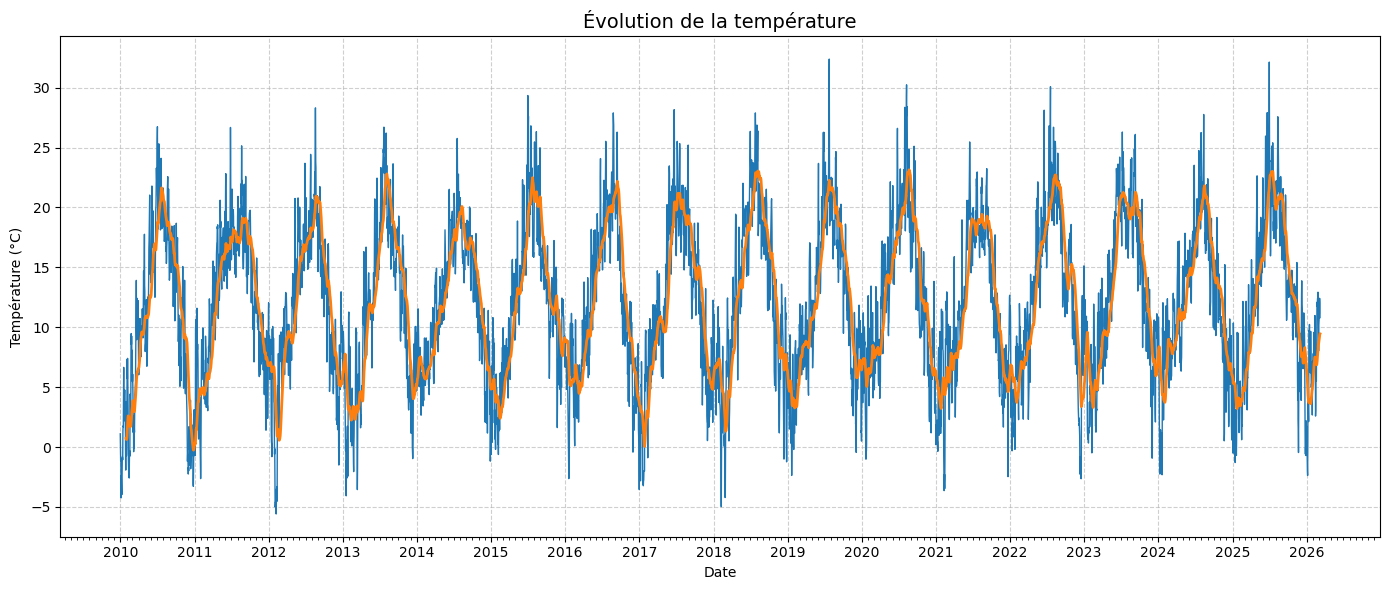

In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# moyenne journalière pour réduire le bruit
df_daily = df.set_index('date').resample('D').mean()

plt.figure(figsize=(14,6))

plt.plot(
    df_daily.index,
    df_daily['temperature_2m'],
    linewidth=1
)

# moyenne glissante (30 jours)
rolling = df_daily['temperature_2m'].rolling(30).mean()
plt.plot(df_daily.index, rolling, linewidth=2)

plt.title("Évolution de la température", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Température (°C)")

# axe temporel lisible
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Le graphique ci-dessus n'est pas très lisible, donc nous allons prendre une range d'une semaine pour faire une meilleure visualisation de l'évolution de la température dans le temps.

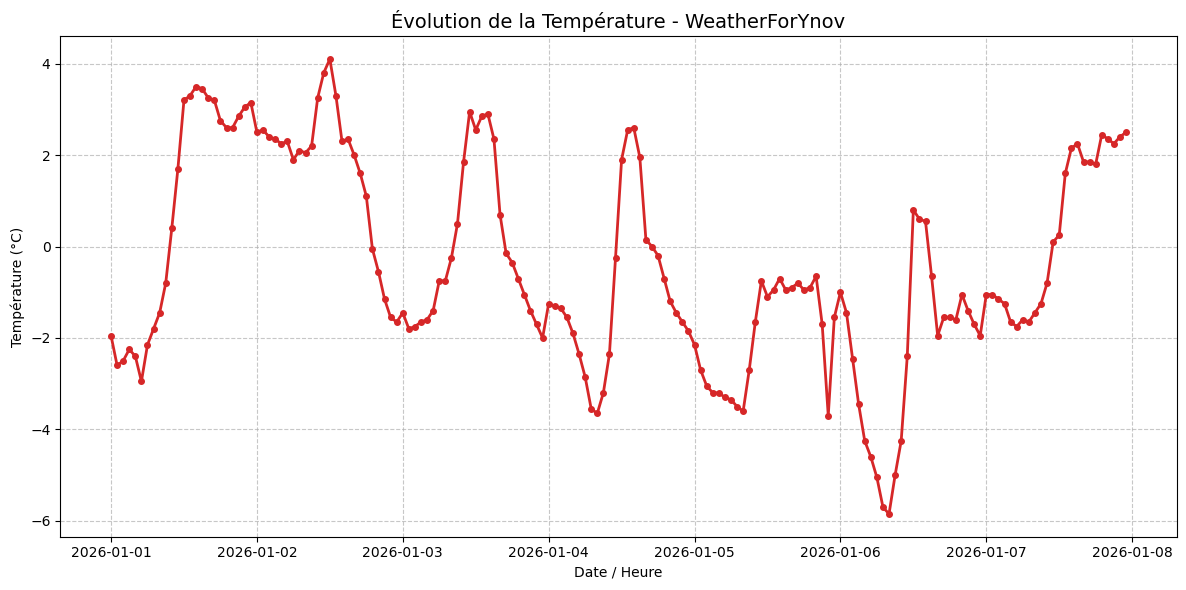

In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(12, 6))
plt.plot(
    df_filtered['date'],
    df_filtered['temperature_2m'],
    color='tab:red',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nous pouvons observer qu'il y a une chute des températures pendant la nuit et qu'il y a une certaine continuité entre les jours.

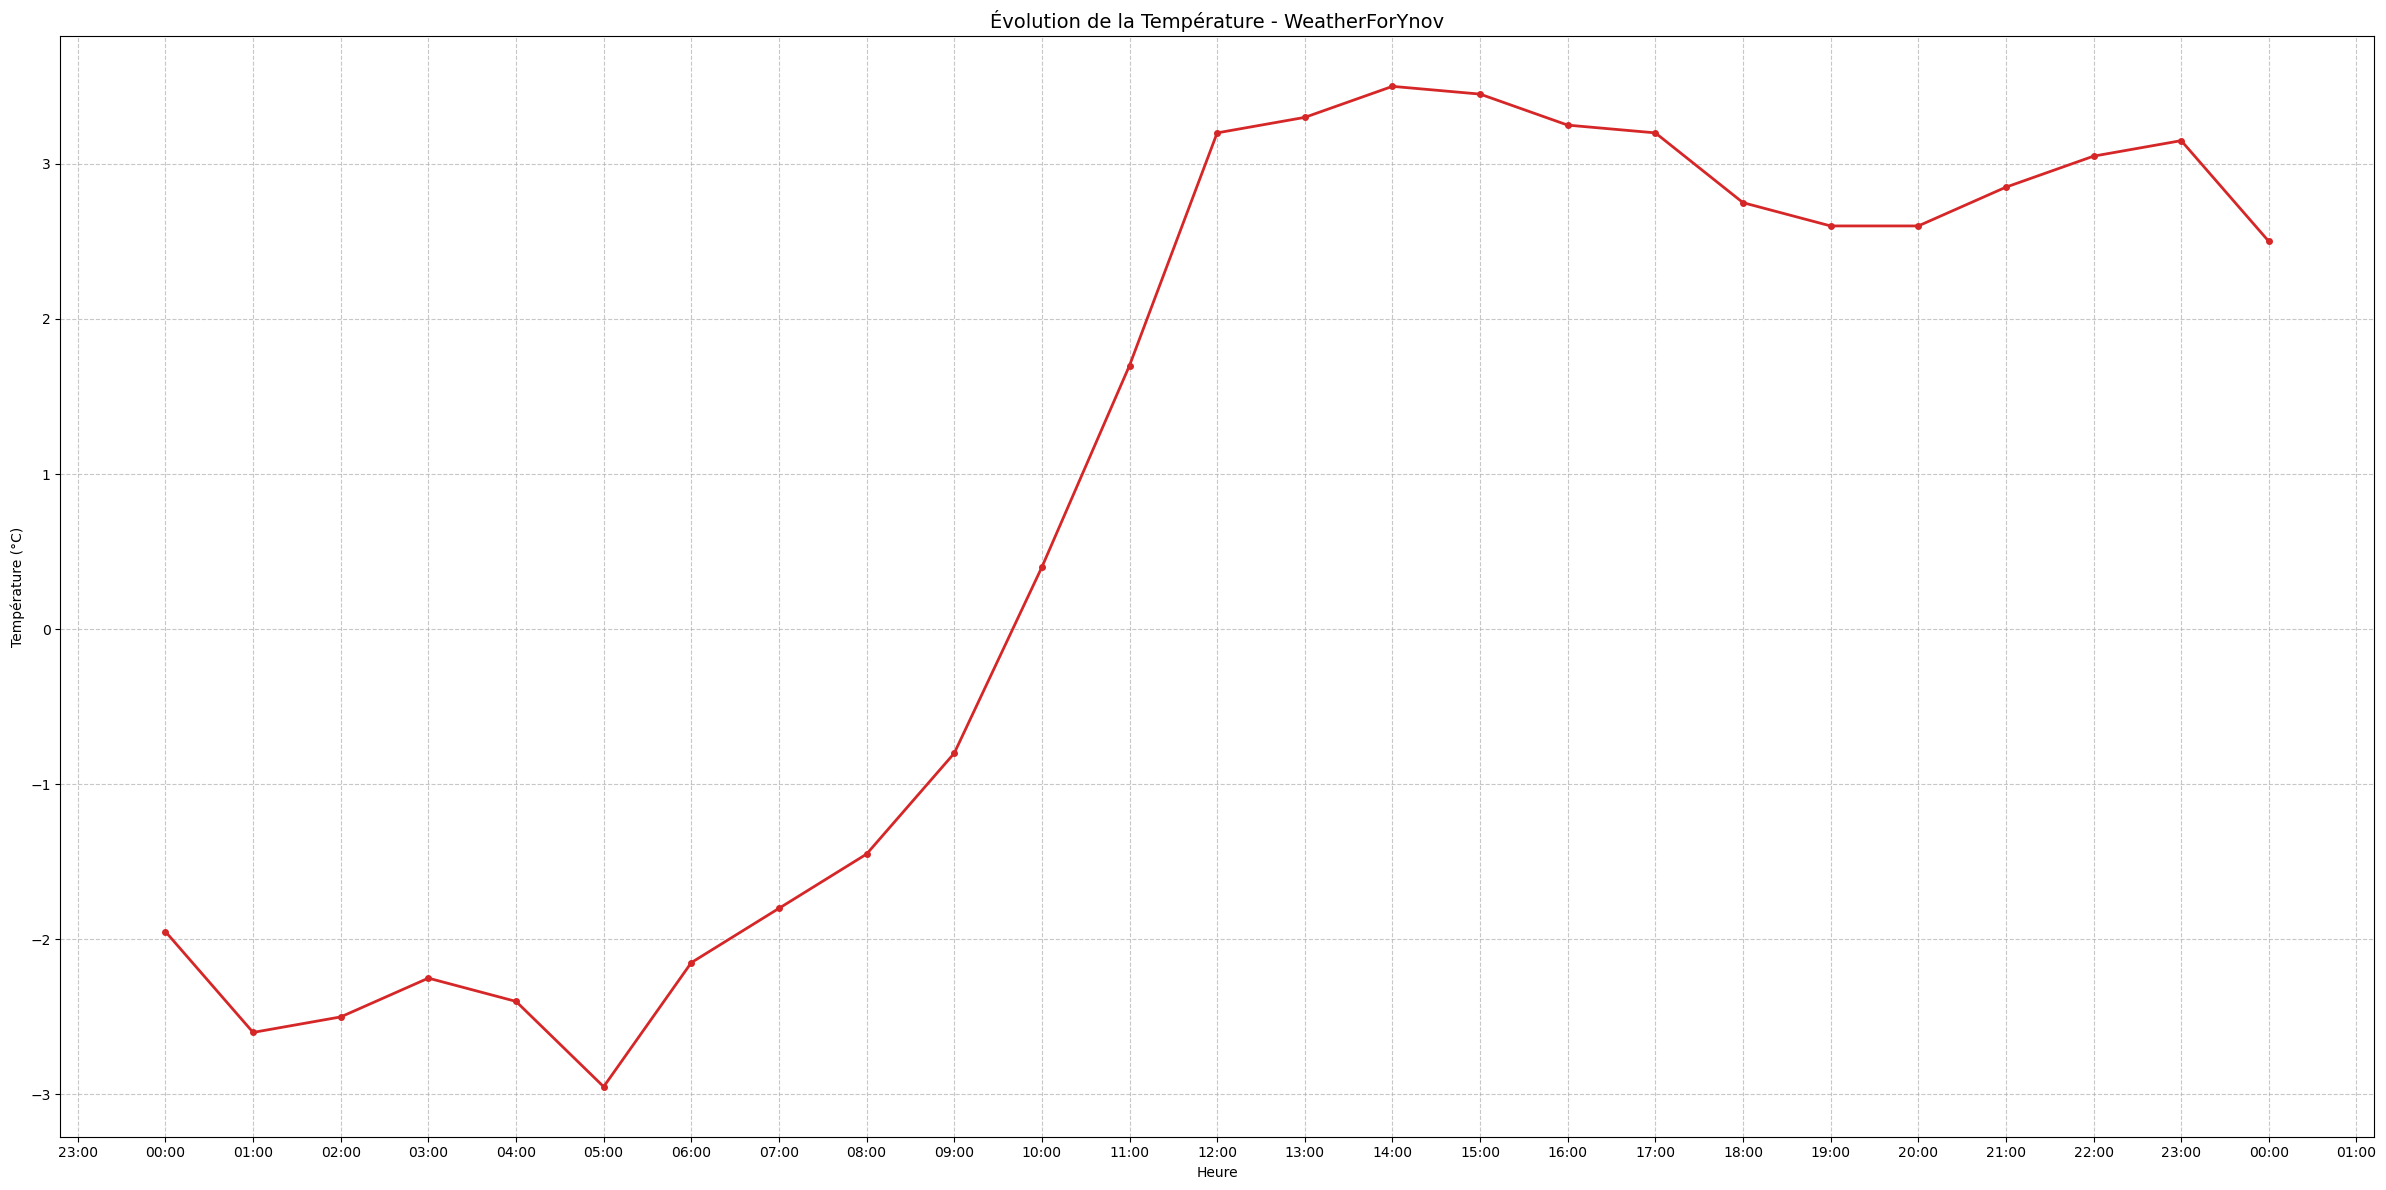

In [5]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-02 00:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(24,12))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ce graphique ici confirme que la température est plus basse la nuit.

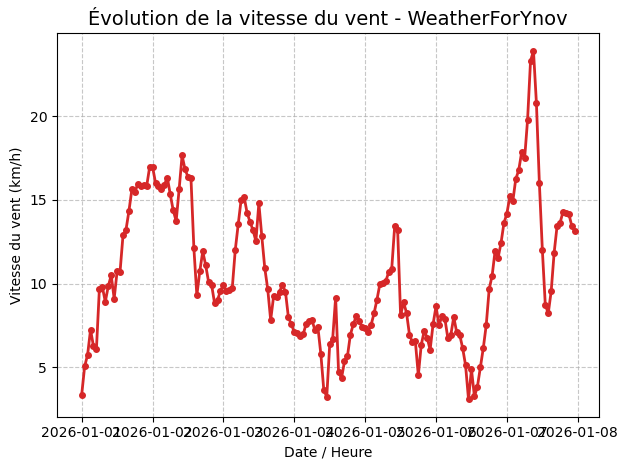

In [9]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['wind_speed_10m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title('Évolution de la vitesse du vent - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Vitesse du vent (km/h)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

On peut observer que la vitesse du vent est étroitement corrélé avec la température. Cependant, on ne peut pas affirmer à 100% qu'ils sont corrélées

KeyError: 'temperature_20m'

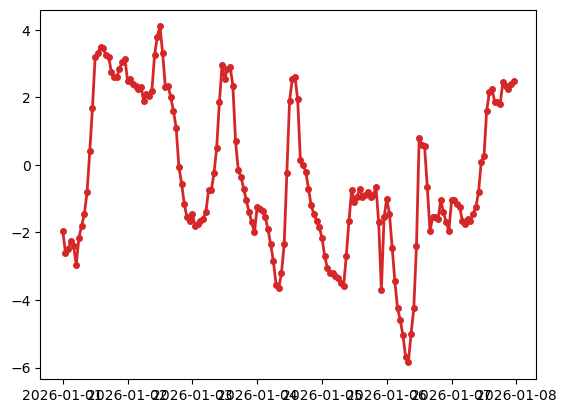

In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title("Évolution de la température à différente altitude - WeatherForYnov", fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

On peut remarquer que les températures à différentes altitudes semblent très liés

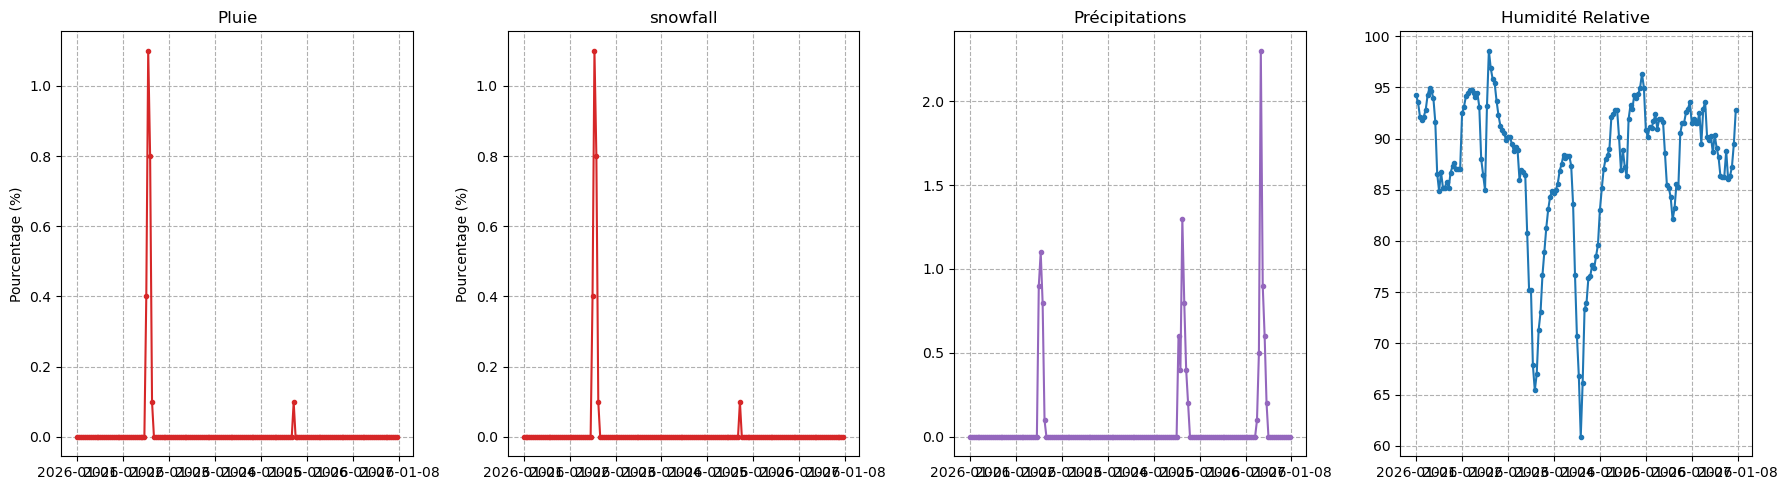

In [13]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 5))

# Graphique 1 : Rain (Pluie)
ax1.plot(df_filtered['date'], df_filtered['rain'], color='tab:red', marker='o', markersize=3)
ax1.set_title('Pluie')
ax1.set_ylabel('Pourcentage (%)')
ax1.grid(True, linestyle='--')

# Graphique 2 : Snowfall (Neige)
ax2.plot(df_filtered['date'], df_filtered['rain'], color='tab:red', marker='o', markersize=3)
ax2.set_title('snowfall')
ax2.set_ylabel('Pourcentage (%)')
ax2.grid(True, linestyle='--')

# Graphique 3 : Précipitations
ax3.plot(df_filtered['date'], df_filtered['precipitation'], color='tab:purple', marker='o', markersize=3)
ax3.set_title('Précipitations')
ax3.grid(True, linestyle='--')

# Graphique 4 : Humidité
ax4.plot(df_filtered['date'], df_filtered['relative_humidity_2m'], color='tab:blue', marker='o', markersize=3)
ax4.set_title('Humidité Relative')
ax4.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

On peut remarquer que la pluie et les précipitations sont liés, cependant, on remarque quand même qu'il y a un facteur de plus qui rentre en compte pour les précipitations, au vu des températures, on pourrait déduire que c'est de la neige. On peut remarquer que la pluie est très peu significative sur la valeur de l'humidité. Néanmoins, on sait qu'il a neigé et que le taux d'humidité est étroitement lié aux faites que la neige a fondu.

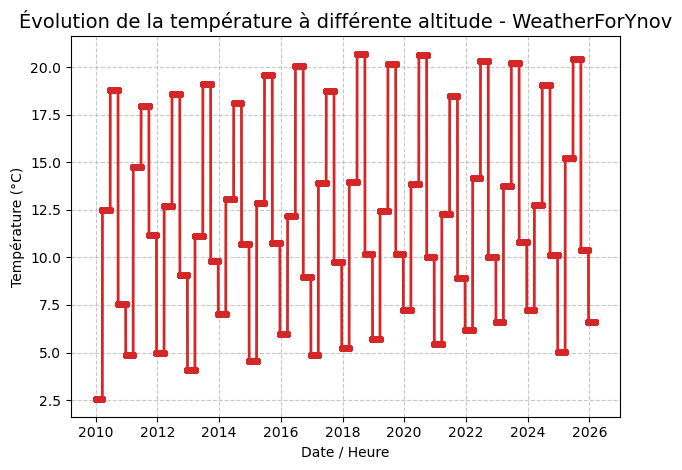

In [23]:
plt.Figure(figsize=(12,6))
plt.plot(df['date'], df['moyenne_temperature_saison'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title("Évolution de la température sur toutes les saisons depuis 2010 - WeatherForYnov", fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Moyenne de Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [24]:
correlation = df.corr()

print(correlation)

ValueError: could not convert string to float: 'Hiver'

On peut observer que dans cette matrice de corrélation, nous avons quelques valeurs qui ont des corrélations. Cependant ces valeurs sont de la même famille "températures à 2m; températures à 20m; températures à 50m" ou alors "pluies; intempéries", mais ces valeurs sont liées par un instant T.

In [15]:
df_shifted = df.shift(-1)

# corrélation entre temperature(t) et toutes les variables à t+1
corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                         0.059677
temperature_2m               0.991894
weather_code                -0.011543
wind_speed_10m              -0.037715
rain                         0.035067
snowfall                    -0.084148
precipitation                0.025760
wind_speed_100m             -0.143088
snow_depth                  -0.227577
apparent_temperature         0.980823
relative_humidity_2m        -0.594994
cloud_cover                 -0.076387
wind_direction_10m           0.038215
soil_temperature_0_to_7cm    0.976157
surface_pressure            -0.082394
is_day                       0.289839
sunshine_duration            0.365733
dtype: float64


On peut voir une forte correlation entre la temperature au moment T0 et le moment T1 

In [16]:
df_shifted = df.shift(-24)

# corrélation entre temperature(t) et toutes les variables à t+1
corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                         0.045742
temperature_2m               0.925235
weather_code                -0.010885
wind_speed_10m              -0.059782
rain                         0.038719
snowfall                    -0.079339
precipitation                0.029928
wind_speed_100m             -0.188106
snow_depth                  -0.235544
apparent_temperature         0.918507
relative_humidity_2m        -0.560854
cloud_cover                 -0.102512
wind_direction_10m           0.062942
soil_temperature_0_to_7cm    0.944540
surface_pressure            -0.063109
is_day                       0.347273
sunshine_duration            0.401192
dtype: float64


On peut observer que la correlation entre la temperature T0 et T1 a baisser.